# Traffic Sign Classification Project Report

## 3. Introduction

This project addresses the critical problem of traffic sign classification using deep learning techniques. Accurate and real-time classification of traffic signs is essential for autonomous vehicles, advanced driver-assistance systems (ADAS), and intelligent transportation systems. Misinterpretation or failure to recognize traffic signs can lead to severe accidents and traffic violations. This notebook explores various Convolutional Neural Network (CNN) architectures, from a basic baseline model to a deeper, regularized model, and finally investigates transfer learning with a pre-trained MobileNetV2 model. The goal is to compare their performance, computational efficiency, and effectiveness in classifying different types of traffic signs.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import time
import keras
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from keras import layers, models, callbacks
from PIL import Image, UnidentifiedImageError
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/Traffic_Sign_-2-20260509T064650Z-3-001.zip"
extract_path = "/content/"

train_dir = "/content/Traffic_Sign_-2/Train"
test_dir = "/content/Traffic_Sign_-2/Test"

if not os.path.isdir(train_dir):
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)
      print("Dataset unzipped successfully.")
else:
    print("Dataset folder already exists; skipping unzip.")

Dataset folder already exists; skipping unzip.


Classes: ['Cautions', 'Crossings', 'DIrection', 'No Entry', 'SpeedLimit']
Total images (Train + Test): 16110
Train images: 16100
Test images:  10

Train distribution:
- Cautions  : 1678
- Crossings : 1828
- DIrection : 2968
- No Entry  : 2938
- SpeedLimit: 6688


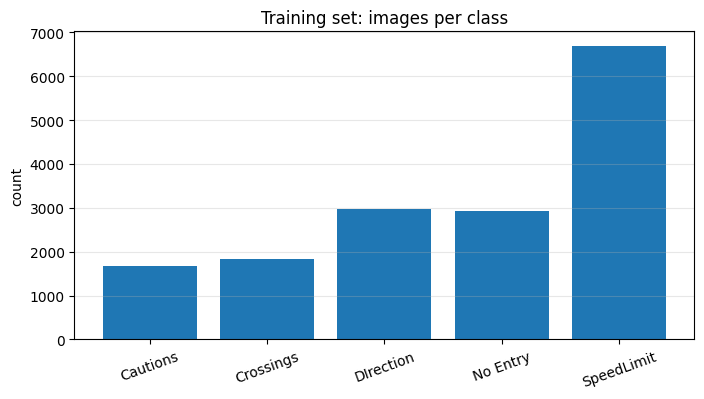

In [ ]:
from pathlib import Path

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

def list_images(folder: Path):
    files = []
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            files.append(p)
    return files

TRAIN_DIR = Path(train_dir)
TEST_DIR = Path(test_dir)

class_dirs = [p for p in TRAIN_DIR.iterdir() if p.is_dir()]
class_names = sorted([p.name for p in class_dirs])
print("Classes:", class_names)

train_counts = {}
train_total = 0
for cls in class_names:
    imgs = list_images(TRAIN_DIR / cls)
    train_counts[cls] = len(imgs)
    train_total += len(imgs)

test_total = len(list_images(TEST_DIR))

total_images = train_total + test_total

print(f"Total images (Train + Test): {total_images}")
print(f"Train images: {train_total}")
print(f"Test images:  {test_total}")
print("\nTrain distribution:")
for k in class_names:
    print(f"- {k:10s}: {train_counts[k]}")

# Bar chart distribution
plt.figure(figsize=(8,4))
plt.bar(list(train_counts.keys()), list(train_counts.values()))
plt.title("Training set: images per class")
plt.ylabel("count")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

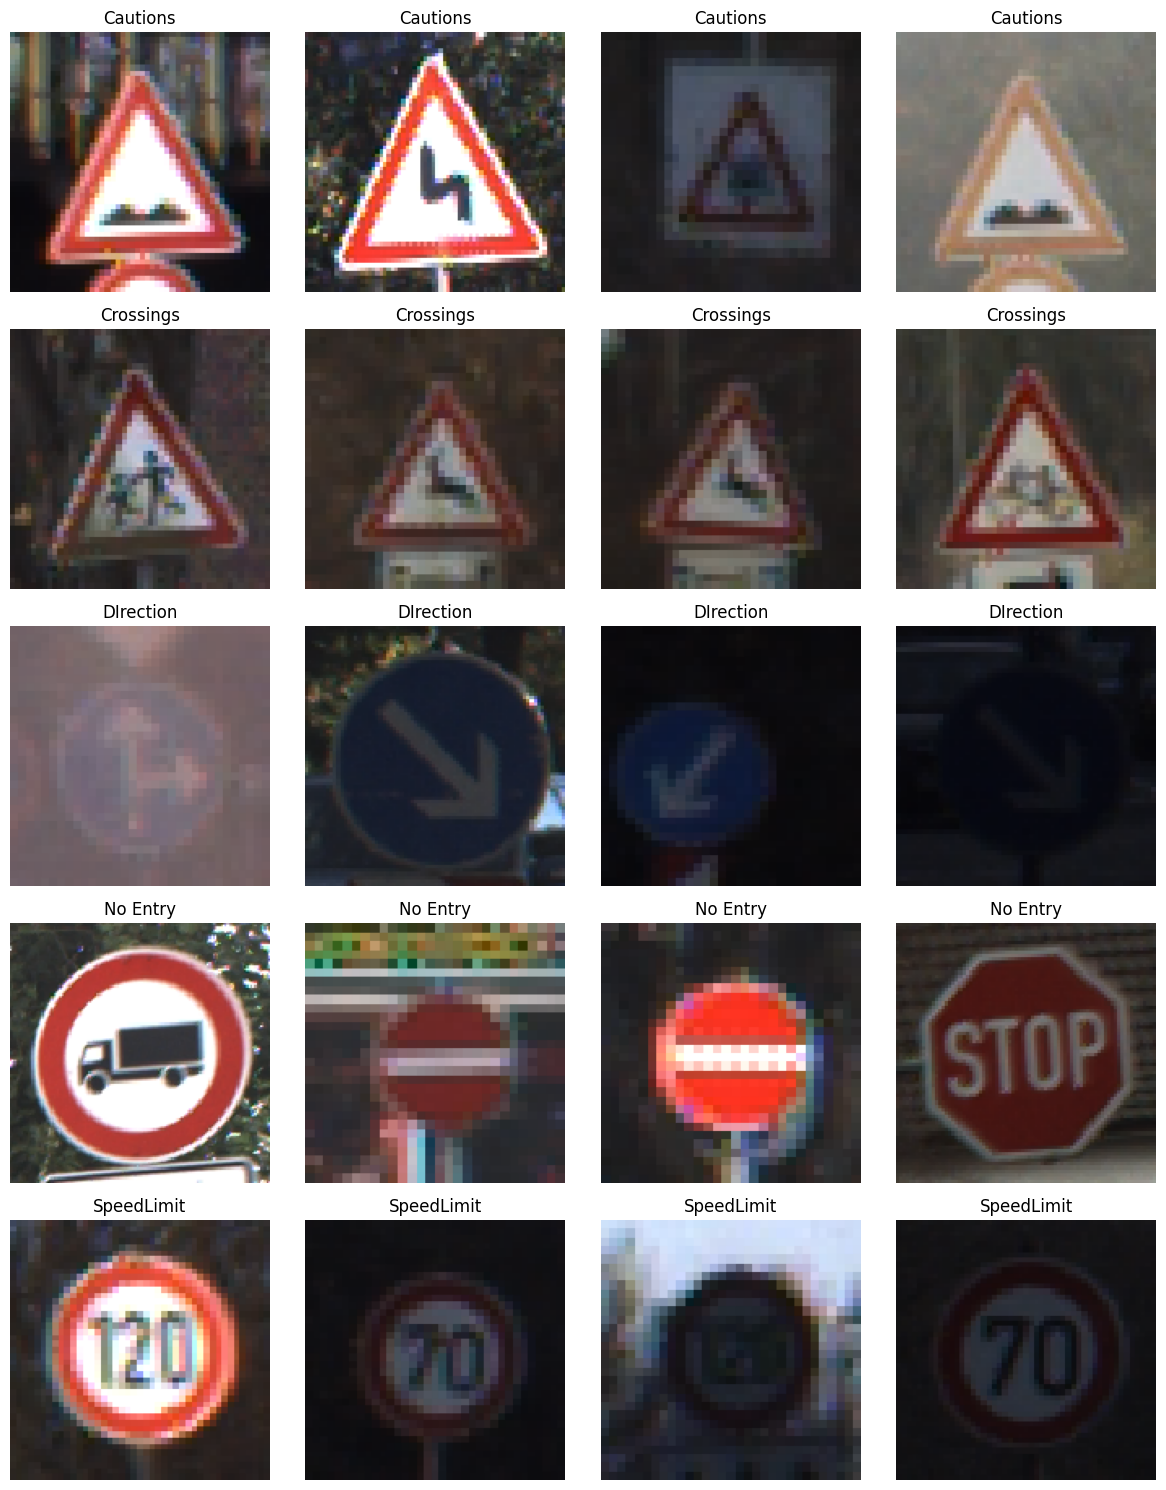

In [ ]:
import random

# Visualize sample images per class

def show_samples_per_class(n_per_class=4, img_size=(160, 160)):
    plt.figure(figsize=(n_per_class*3, len(class_names)*3))
    plot_idx = 1
    for cls in class_names:
        imgs = list_images(TRAIN_DIR / cls)
        picks = random.sample(imgs, k=min(n_per_class, len(imgs)))
        for p in picks:
            img = keras.utils.load_img(p, target_size=img_size)
            ax = plt.subplot(len(class_names), n_per_class, plot_idx)
            ax.imshow(img)
            ax.set_title(cls)
            ax.axis("off")
            plot_idx += 1
    plt.tight_layout()
    plt.show()

show_samples_per_class(n_per_class=4, img_size=(160, 160))

In [ ]:
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split

IMG_SIZE = (64, 64)   # can increase to (96,96) or (128,128) if you have GPU
BATCH_SIZE = 32
VAL_SPLIT = 0.2
SEED = 42 # Define the SEED for reproducibility

# Assuming IMG_EXTS is defined in a previous cell, e.g., DOUYsCRMkT9u
# For robustness, you could redefine it here if needed:
# IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

def get_image_paths_and_labels(base_dir: Path):
    all_image_paths = []
    all_image_labels = []
    class_names = sorted([item.name for item in base_dir.iterdir() if item.is_dir()])
    class_to_idx = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_dir = base_dir / class_name
        # Use the existing list_images function from cell DOUYsCRMkT9u
        for img_path in list_images(class_dir):
            try:
                # Attempt to open the image to check for validity using PIL
                with Image.open(img_path) as img:
                    img.verify() # Verify integrity
                all_image_paths.append(str(img_path))
                all_image_labels.append(class_to_idx[class_name])
            except (IOError, SyntaxError, UnidentifiedImageError) as e:
                print(f"Skipping corrupted or unidentifiable image (PIL check): {img_path} - {e}")
    return all_image_paths, all_image_labels, class_names

# Get paths and labels for the training directory, filtering out invalid images
all_train_image_paths, all_train_image_labels, class_names = get_image_paths_and_labels(TRAIN_DIR)
num_classes = len(class_names)
print("Class names:", class_names)
print("Num classes:", num_classes)
print(f"Found {len(all_train_image_paths)} valid images for training/validation.")

# Split into training and validation sets
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_train_image_paths, all_train_image_labels, test_size=VAL_SPLIT, random_state=SEED, stratify=all_train_image_labels
)

# Preprocessing: normalize to [0,1]
normalization = layers.Rescaling(1./255)

# Data augmentation (applied only to training)
augment = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
    ],
    name="augmentation",
)

# Function to load and preprocess images from file paths
def preprocess_image(filepath, label, augment_data=False):
    img = tf.io.read_file(filepath)
    # decode_image handles JPEG, PNG, GIF, BMP, WebP. expand_animations=False for GIFs.
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = normalization(img) # Apply normalization

    if augment_data:
        img = augment(img, training=True) # Apply augmentation

    return img, label

AUTOTUNE = tf.data.AUTOTUNE

# Create TensorFlow datasets from tensor slices of file paths and labels
train_ds = tf.data.Dataset.from_tensor_slices((tf.constant(train_paths), tf.constant(train_labels)))
val_ds = tf.data.Dataset.from_tensor_slices((tf.constant(val_paths), tf.constant(val_labels)))

train_ds_prep = (
    train_ds
    .shuffle(buffer_size=1000) # Shuffle paths before mapping
    .map(lambda x, y: preprocess_image(x, y, augment_data=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

val_ds_prep = (
    val_ds
    .map(lambda x, y: preprocess_image(x, y, augment_data=False), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

Skipping corrupted or unidentifiable image (PIL check): /content/Traffic_Sign_-2/Train/Cautions/00030_00004_00000.png - cannot identify image file '/content/Traffic_Sign_-2/Train/Cautions/00030_00004_00000.png'
Skipping corrupted or unidentifiable image (PIL check): /content/Traffic_Sign_-2/Train/Cautions/00022_00003_00015.png - cannot identify image file '/content/Traffic_Sign_-2/Train/Cautions/00022_00003_00015.png'
Skipping corrupted or unidentifiable image (PIL check): /content/Traffic_Sign_-2/Train/Cautions/00023_00007_00006.png - cannot identify image file '/content/Traffic_Sign_-2/Train/Cautions/00023_00007_00006.png'
Skipping corrupted or unidentifiable image (PIL check): /content/Traffic_Sign_-2/Train/Cautions/00022_00006_00005.png - cannot identify image file '/content/Traffic_Sign_-2/Train/Cautions/00022_00006_00005.png'
Skipping corrupted or unidentifiable image (PIL check): /content/Traffic_Sign_-2/Train/Cautions/00021_00004_00014.png - cannot identify image file '/content

## 4. Dataset

The dataset used for this project is the 'Traffic Sign' dataset, extracted from a zip file located at `/content/drive/MyDrive/Traffic_Sign_-2-20260509T064650Z-3-001.zip`. The dataset is divided into training and testing sets, with the training set containing 16100 images and the testing set containing 10 images. The images are categorized into 5 classes: 'Cautions', 'Crossings', 'DIrection', 'No Entry', and 'SpeedLimit'.

**Key characteristics:**
- **Total images:** 16110 (16100 train, 10 test)
- **Classes:** 5
- **Image preprocessing:** Images are resized to `(64, 64)` and normalized to the range `[0, 1]`. A `VAL_SPLIT` of 0.2 is used for training and validation sets.
- **Data Augmentation:** Applied to the training set including random horizontal flips, rotations, and zooms to enhance model generalization.

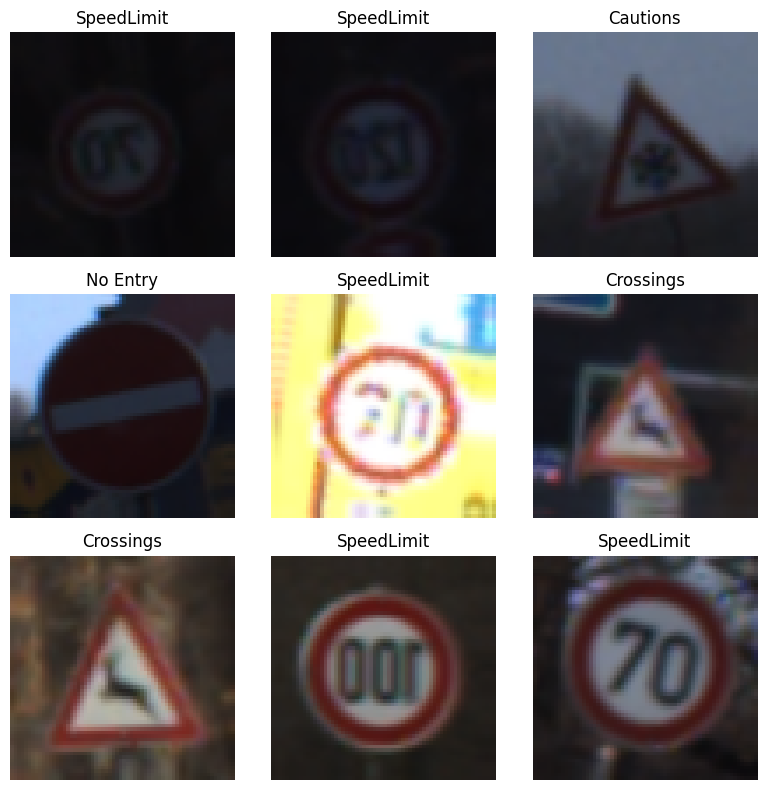

In [ ]:
# Visualize augmentation examples

def show_augmented_examples(ds, n=9):
    for images, labels in ds.take(1):
        plt.figure(figsize=(8,8))
        for i in range(n):
            ax = plt.subplot(3, 3, i+1)
            plt.imshow(images[i].numpy())
            plt.title(class_names[int(labels[i])])
            plt.axis("off")
        plt.tight_layout()
        plt.show()

show_augmented_examples(train_ds_prep, n=9)

In [ ]:
# Baseline CNN model

baseline_model = keras.Sequential(
    [
        layers.Input(shape=(*IMG_SIZE, 3)),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        # 3 fully-connected layers
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),

        layers.Dense(num_classes, activation="softmax"),
    ],
    name="baseline_cnn",
)

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,133 (8.51 MB)

 Trainable params: 2,232,133 (8.51 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Methodology

### Baseline Model

The baseline model is a standard Convolutional Neural Network (CNN) designed for image classification. It consists of:
- **Convolutional Layers:** 3 convolutional layers with `ReLU` activation, each followed by a `MaxPooling2D` layer for downsampling.
- **Fully Connected Layers:** After flattening, there are 3 dense layers with `ReLU` activation.
- **Output Layer:** A final dense layer with `softmax` activation for multiclass classification.

**Configuration:**
- Input shape: `(64, 64, 3)`
- Optimizer: `Adam` with a default learning rate of `1e-3`.
- Loss function: `SparseCategoricalCrossentropy`.
- Metrics: `accuracy`.

Class counts (train split): {'Cautions': 1337, 'Crossings': 1457, 'DIrection': 2369, 'No Entry': 2344, 'SpeedLimit': 5345}
Class weights: {'Cautions': 1.9225130890052355, 'Crossings': 1.7641729581331502, 'DIrection': 1.085014774166315, 'No Entry': 1.0965870307167236, 'SpeedLimit': 0.4808980355472404}
Epoch 1/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - accuracy: 0.8044 - loss: 0.5120 - val_accuracy: 0.9396 - val_loss: 0.1457
Epoch 2/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9492 - loss: 0.1851 - val_accuracy: 0.9605 - val_loss: 0.0955
Epoch 3/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9795 - loss: 0.0856 - val_accuracy: 0.9897 - val_loss: 0.0346
Epoch 4/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9828 - loss: 0.0718 - val_accuracy: 0.9841 - val_loss: 0.0486
Epoch 5/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9913 - loss: 0.0365 - val_accuracy: 0.9732 - val_loss: 0.0769
Epoch 6/15
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - a

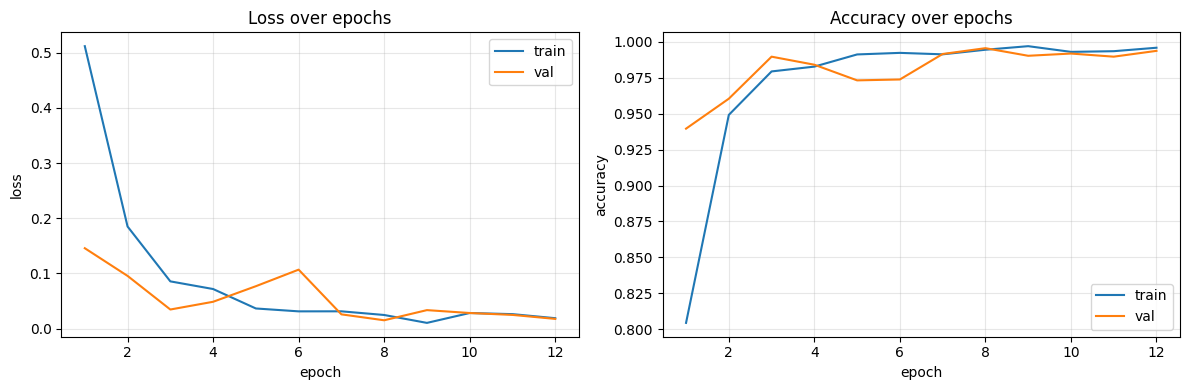

In [ ]:
# Train baseline model (with class-imbalance handling via class weights)

EPOCHS = 15

# Compute class weights from the training split
# (np.atleast_1d handles any edge-case scalar label tensors)
train_label_list = []
for _, y in train_ds:  # uses the same split created earlier
    train_label_list.append(np.atleast_1d(y.numpy()))
train_labels = np.concatenate(train_label_list, axis=0)

class_counts = np.bincount(train_labels.astype(int), minlength=num_classes)
class_weight = {
    i: (len(train_labels) / (num_classes * class_counts[i])) if class_counts[i] > 0 else 0.0
    for i in range(num_classes)
}

print("Class counts (train split):", dict(zip(class_names, class_counts.tolist())))
print("Class weights:", {class_names[k]: float(v) for k, v in class_weight.items()})

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
]

history = baseline_model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight,
)

# Plot loss/accuracy curves
hist = history.history
epochs_ran = range(1, len(hist["loss"]) + 1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs_ran, hist["loss"], label="train")
plt.plot(epochs_ran, hist["val_loss"], label="val")
plt.title("Loss over epochs")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_ran, hist["accuracy"], label="train")
plt.plot(epochs_ran, hist["val_accuracy"], label="val")
plt.title("Accuracy over epochs")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Validation classification report:

              precision    recall  f1-score   support

    Cautions     0.9909    0.9731    0.9819       334
   Crossings     0.9757    0.9918    0.9837       364
   DIrection     1.0000    1.0000    1.0000       592
    No Entry     0.9983    0.9983    0.9983       587
  SpeedLimit     0.9993    0.9993    0.9993      1336

    accuracy                         0.9956      3213
   macro avg     0.9928    0.9925    0.9926      3213
weighted avg     0.9957    0.9956    0.9956      3213



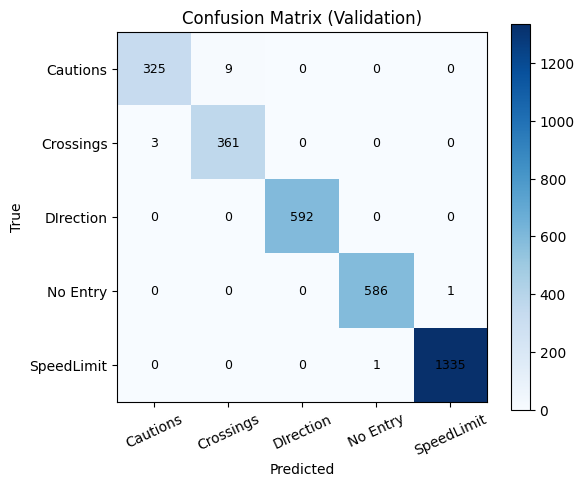

In [ ]:
# Evaluation: accuracy, precision, recall, F1 on validation set

# Gather y_true and y_pred across the full val set

y_true = []
y_pred = []

for x_batch, y_batch in val_ds_prep:
    probs = baseline_model.predict(x_batch, verbose=0)
    preds = np.argmax(probs, axis=1)
    y_true.append(y_batch.numpy())
    y_pred.append(preds)

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print("Validation classification report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names, rotation=25)
plt.yticks(range(num_classes), class_names)
plt.colorbar()

# annotate
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

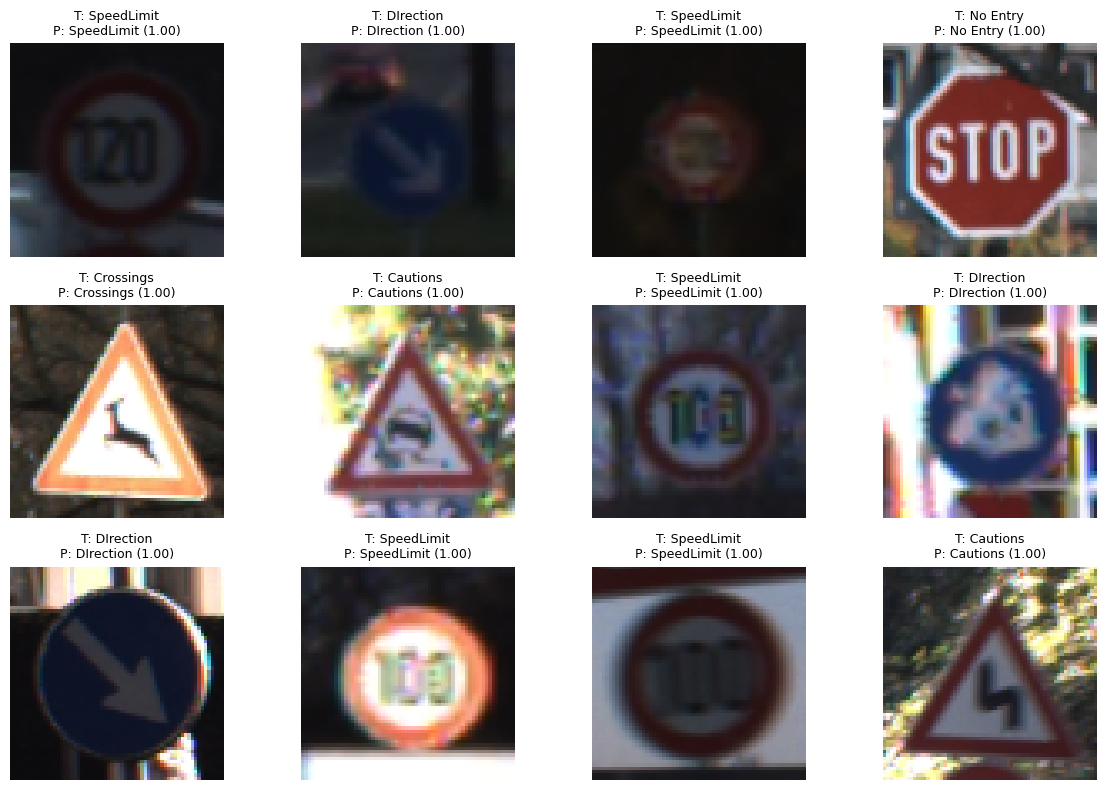

In [ ]:
# Inference on sample validation images + plot results

def predict_and_plot(ds, n=12):
    for images, labels in ds.take(1):
        probs = baseline_model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)

        plt.figure(figsize=(12, 8))
        for i in range(min(n, images.shape[0])):
            ax = plt.subplot(3, 4, i+1)
            plt.imshow(images[i].numpy())
            true_name = class_names[int(labels[i])]
            pred_name = class_names[int(preds[i])]
            conf = float(np.max(probs[i]))
            ax.set_title(f"T: {true_name}\nP: {pred_name} ({conf:.2f})", fontsize=9)
            plt.axis("off")
        plt.tight_layout()
        plt.show()

# Use non-augmented (normalized only) batch for clearer visualization
# val_ds_prep is already normalized and not augmented, so we can use it directly.
val_for_viz = val_ds_prep.ignore_errors()
predict_and_plot(val_for_viz, n=12)

In [ ]:
import time

# Deeper CNN model (>= 2x conv layers vs baseline) + regularization

WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.3

l2 = keras.regularizers.l2(WEIGHT_DECAY)

deep_model = keras.Sequential(
    [
        layers.Input(shape=(*IMG_SIZE, 3)),

        # Block 1 (2 convs)
        layers.Conv2D(32, (3,3), padding="same", use_bias=False, kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(32, (3,3), padding="same", use_bias=False, kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(DROPOUT_RATE),

        # Block 2 (2 convs)
        layers.Conv2D(64, (3,3), padding="same", use_bias=False, kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(64, (3,3), padding="same", use_bias=False, kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(DROPOUT_RATE),

        # Block 3 (2 convs)
        layers.Conv2D(128, (3,3), padding="same", use_bias=False, kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(128, (3,3), padding="same", use_bias=False, kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(DROPOUT_RATE),

        layers.Flatten(),

        # Keep 3 fully-connected layers (regularized)
        layers.Dense(256, activation="relu", kernel_regularizer=l2),
        layers.Dropout(0.4),
        layers.Dense(128, activation="relu", kernel_regularizer=l2),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu", kernel_regularizer=l2),

        layers.Dense(num_classes, activation="softmax"),
    ],
    name="deep_cnn_regularized",
)

deep_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

deep_model.summary()


Model: "deep_cnn_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 128)    │             

 Total params: 2,427,237 (9.26 MB)

 Trainable params: 2,426,341 (9.26 MB)

 Non-trainable params: 896 (3.50 KB)

### Deeper Model with Regularization

To improve performance and combat overfitting, a deeper CNN architecture was developed, incorporating regularization techniques:
- **Architecture:** The model consists of 3 blocks, each containing two `Conv2D` layers, `BatchNormalization`, `ReLU` activation, `MaxPooling2D`, and `Dropout`.
- **Regularization:**
  - `L2 regularization` (`WEIGHT_DECAY = 1e-4`) applied to convolutional and dense layers.
  - `Batch Normalization` layers are used to stabilize and accelerate training.
  - `Dropout` layers (`DROPOUT_RATE = 0.3` for conv blocks, `0.4` and `0.3` for dense layers) are included to prevent overfitting.
- **Fully Connected Layers:** 3 dense layers, also regularized with L2 and followed by dropout.
- **Optimizer:** `Adam` with a learning rate of `1e-3`.
- **Loss Function:** `SparseCategoricalCrossentropy`.
- **Metrics:** `accuracy`.

Epoch 1/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.5549 - loss: 1.2248 - val_accuracy: 0.8073 - val_loss: 0.6261 - learning_rate: 0.0010
Epoch 2/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8108 - loss: 0.6084 - val_accuracy: 0.7809 - val_loss: 0.6719 - learning_rate: 0.0010
Epoch 3/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8777 - loss: 0.4685 - val_accuracy: 0.8005 - val_loss: 0.5605 - learning_rate: 0.0010
Epoch 4/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9272 - loss: 0.3565 - val_accuracy: 0.9583 - val_loss: 0.2004 - learning_rate: 0.0010
Epoch 5/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9530 - loss: 0.2791 - val_accuracy: 0.9589 - val_loss: 0.2184 - learning_rate: 0.0010
Epoch 6/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9622 - loss: 0.2441 - val_accuracy: 0.9673 - val_loss: 0.1840 - learning_rate: 0.0010
Epoch 7/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9751 - loss: 

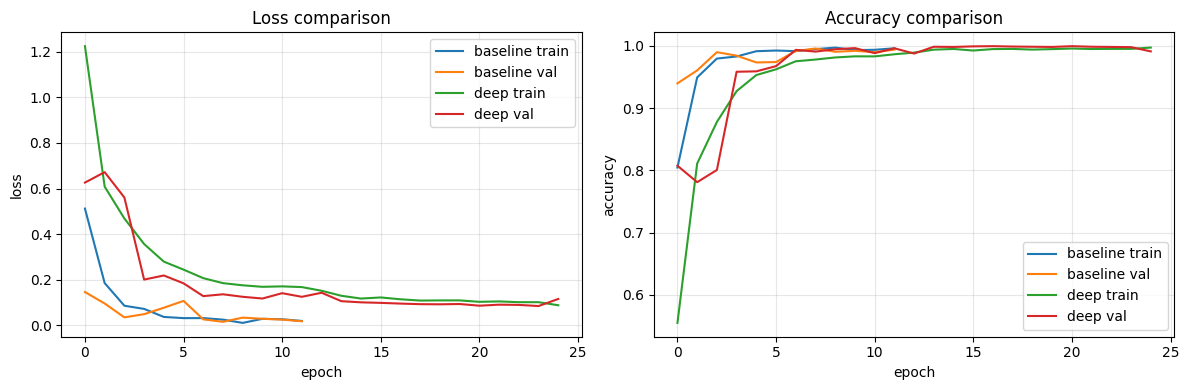

In [ ]:
# Train deeper model + record training time, then compare curves vs baseline

DEEP_EPOCHS = 25

deep_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]

start = time.time()
deep_history = deep_model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=DEEP_EPOCHS,
    callbacks=deep_callbacks,
    class_weight=class_weight,
)
elapsed = time.time() - start
print(f"Deeper model training time: {elapsed:.1f}s")

# Overlay loss curves: baseline vs deep
b = history.history
d = deep_history.history

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(b["loss"], label="baseline train")
plt.plot(b["val_loss"], label="baseline val")
plt.plot(d["loss"], label="deep train")
plt.plot(d["val_loss"], label="deep val")
plt.title("Loss comparison")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1,2,2)
plt.plot(b["accuracy"], label="baseline train")
plt.plot(b["val_accuracy"], label="baseline val")
plt.plot(d["accuracy"], label="deep train")
plt.plot(d["val_accuracy"], label="deep val")
plt.title("Accuracy comparison")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Deeper model classification report (Validation):

              precision    recall  f1-score   support

    Cautions     0.9940    0.9970    0.9955       334
   Crossings     1.0000    0.9945    0.9972       364
   DIrection     0.9966    1.0000    0.9983       592
    No Entry     0.9966    0.9983    0.9974       587
  SpeedLimit     0.9993    0.9978    0.9985      1336

    accuracy                         0.9978      3213
   macro avg     0.9973    0.9975    0.9974      3213
weighted avg     0.9978    0.9978    0.9978      3213



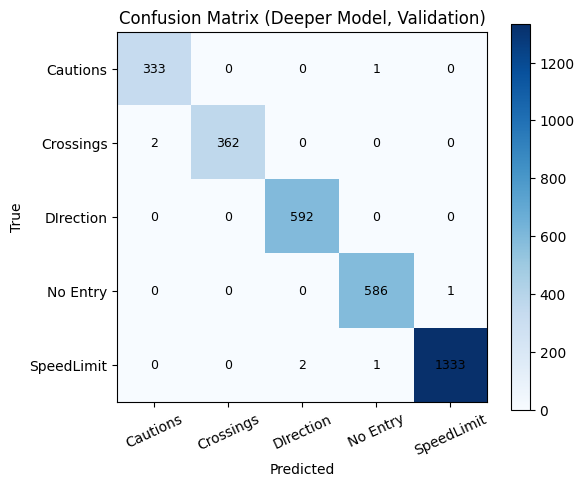

In [ ]:
# Evaluate deeper model (same metrics as baseline)

deep_y_true = []
deep_y_pred = []

for x_batch, y_batch in val_ds_prep:
    probs = deep_model.predict(x_batch, verbose=0)
    preds = np.argmax(probs, axis=1)
    deep_y_true.append(y_batch.numpy())
    deep_y_pred.append(preds)

deep_y_true = np.concatenate(deep_y_true)
deep_y_pred = np.concatenate(deep_y_pred)

print("Deeper model classification report (Validation):\n")
print(classification_report(deep_y_true, deep_y_pred, target_names=class_names, digits=4))

deep_cm = confusion_matrix(deep_y_true, deep_y_pred)
plt.figure(figsize=(6,5))
plt.imshow(deep_cm, cmap="Blues")
plt.title("Confusion Matrix (Deeper Model, Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names, rotation=25)
plt.yticks(range(num_classes), class_names)
plt.colorbar()
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, deep_cm[i, j], ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.show()

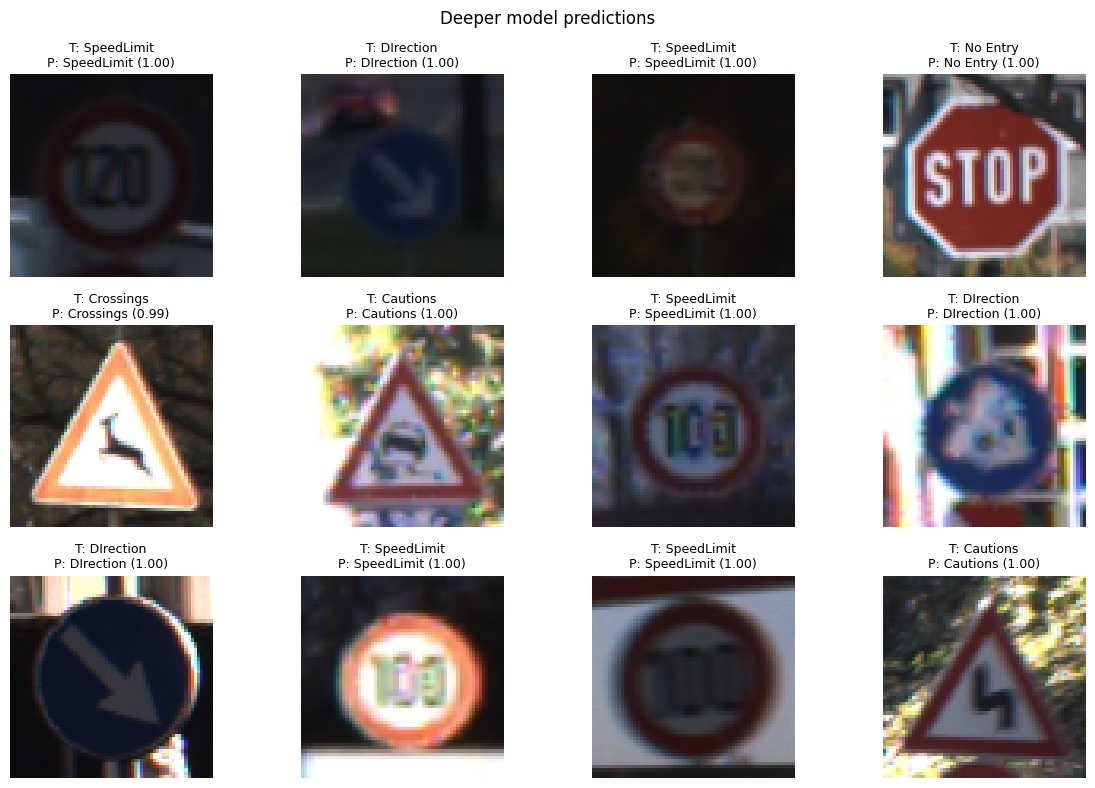

In [ ]:
# Inference with deeper model on sample images

def predict_and_plot_model(model, ds, n=12, title=""):
    for images, labels in ds.take(1):
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)

        plt.figure(figsize=(12, 8))
        if title:
            plt.suptitle(title)
        for i in range(min(n, images.shape[0])):
            ax = plt.subplot(3, 4, i+1)
            plt.imshow(images[i].numpy())
            true_name = class_names[int(labels[i])]
            pred_name = class_names[int(preds[i])]
            conf = float(np.max(probs[i]))
            ax.set_title(f"T: {true_name}\nP: {pred_name} ({conf:.2f})", fontsize=9)
            plt.axis("off")
        plt.tight_layout()
        plt.show()

# Use the already-preprocessed validation pipeline to avoid any file/path tensors
val_for_viz = val_ds_prep.ignore_errors()
predict_and_plot_model(deep_model, val_for_viz, n=12, title="Deeper model predictions")

In [ ]:
import time

# Utility helpers for fair comparisons

def eval_on_val(model, ds):
    y_true_list, y_pred_list = [], []
    for x_batch, y_batch in ds:
        probs = model.predict(x_batch, verbose=0)
        preds = np.argmax(probs, axis=1)
        y_true_list.append(y_batch.numpy())
        y_pred_list.append(preds)
    y_true = np.concatenate(y_true_list)
    y_pred = np.concatenate(y_pred_list)
    # Fix: Explicitly pass the full range of labels to handle cases where a class might be missing from y_true
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4, output_dict=True, labels=list(range(num_classes)))
    return {
        "accuracy": float(report["accuracy"]),
        "macro_f1": float(report["macro avg"]["f1-score"]),
        "weighted_f1": float(report["weighted avg"]["f1-score"]),
        "report_dict": report,
    }

def plot_histories(histories, keys=("loss", "val_loss"), title=""):
    plt.figure(figsize=(10,4))
    for name, h in histories.items():
        for k in keys:
            plt.plot(h.history[k], label=f"{name} {k}")
    plt.title(title)
    plt.xlabel("epoch")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

In [ ]:
# 1) Baseline vs deeper performance (metrics + efficiency)

baseline_metrics = eval_on_val(baseline_model, val_ds_prep.ignore_errors())
deep_metrics = eval_on_val(deep_model, val_ds_prep.ignore_errors())

print("Baseline metrics:")
print({k: v for k, v in baseline_metrics.items() if k != "report_dict"})
print("\nDeeper metrics:")
print({k: v for k, v in deep_metrics.items() if k != "report_dict"})

# Training time notes
print("\nTraining time notes:")
print("- Baseline training time: (not timed unless you wrapped it; optional timing cell below)")
print("- Deeper training time: printed in 2.5.3 training cell as 'Deeper model training time: ...s'")

Baseline metrics:
{'accuracy': 0.9956427015250545, 'macro_f1': 0.9926144514867452, 'weighted_f1': 0.9956410412875424}

Deeper metrics:
{'accuracy': 0.9978213507625272, 'macro_f1': 0.9974046429319261, 'weighted_f1': 0.9978216471025754}

Training time notes:
- Baseline training time: (not timed unless you wrapped it; optional timing cell below)
- Deeper training time: printed in 2.5.3 training cell as 'Deeper model training time: ...s'


In [ ]:
# Optional: re-train baseline with timing (ONLY if you need an exact baseline time)
# NOTE: This will train again.

TIME_BASELINE = False

if TIME_BASELINE:
    baseline_model_timed = keras.models.clone_model(baseline_model)
    baseline_model_timed.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    start = time.time()
    baseline_history_timed = baseline_model_timed.fit(
        train_ds_prep,
        validation_data=val_ds_prep,
        epochs=EPOCHS,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1,
    )
    baseline_elapsed = time.time() - start
    print(f"Baseline model training time: {baseline_elapsed:.1f}s")

In [ ]:
# 1) Baseline vs deeper performance (metrics + efficiency)

baseline_metrics = eval_on_val(baseline_model, val_ds_prep.ignore_errors())
deep_metrics = eval_on_val(deep_model, val_ds_prep.ignore_errors())

print("Baseline metrics:")
print({k: v for k, v in baseline_metrics.items() if k != "report_dict"})
print("\nDeeper metrics:")
print({k: v for k, v in deep_metrics.items() if k != "report_dict"})

# Training time notes
print("\nTraining time notes:")
print("- Baseline training time: (not timed unless you wrapped it; optional timing cell below)")
print("- Deeper training time: printed in 2.5.3 training cell as 'Deeper model training time: ...s'")

Baseline metrics:
{'accuracy': 0.9956427015250545, 'macro_f1': 0.9926144514867452, 'weighted_f1': 0.9956410412875424}

Deeper metrics:
{'accuracy': 0.9978213507625272, 'macro_f1': 0.9974046429319261, 'weighted_f1': 0.9978216471025754}

Training time notes:
- Baseline training time: (not timed unless you wrapped it; optional timing cell below)
- Deeper training time: printed in 2.5.3 training cell as 'Deeper model training time: ...s'


Epoch 1/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.2277 - loss: 1.7827 - val_accuracy: 0.4143 - val_loss: 1.7096 - learning_rate: 0.0100
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3212 - loss: 1.6858 - val_accuracy: 0.4071 - val_loss: 1.5602 - learning_rate: 0.0100
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6178 - loss: 1.0404 - val_accuracy: 0.8002 - val_loss: 0.5418 - learning_rate: 0.0100
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8095 - loss: 0.6126 - val_accuracy: 0.8064 - val_loss: 0.5136 - learning_rate: 0.0100
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8542 - loss: 0.5106 - val_accuracy: 0.8808 - val_loss: 0.3028 - learning_rate: 0.0100
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8633 - loss: 0.4796 - val_accuracy: 0.8848 - val_loss: 0.2783 - learning_rate: 0.0100
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8754 - loss: 0

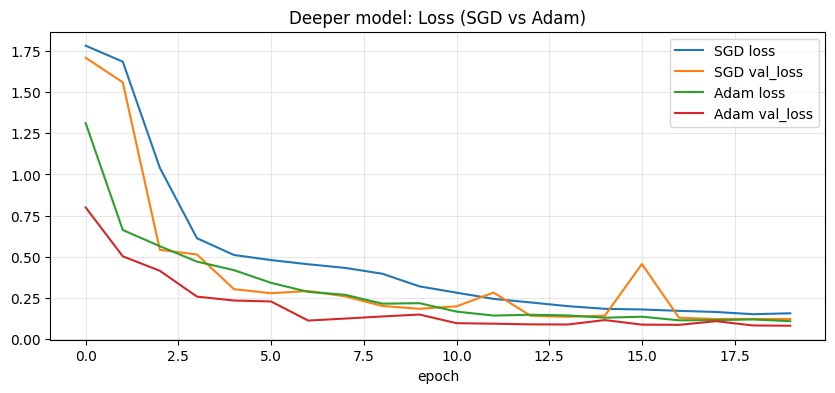

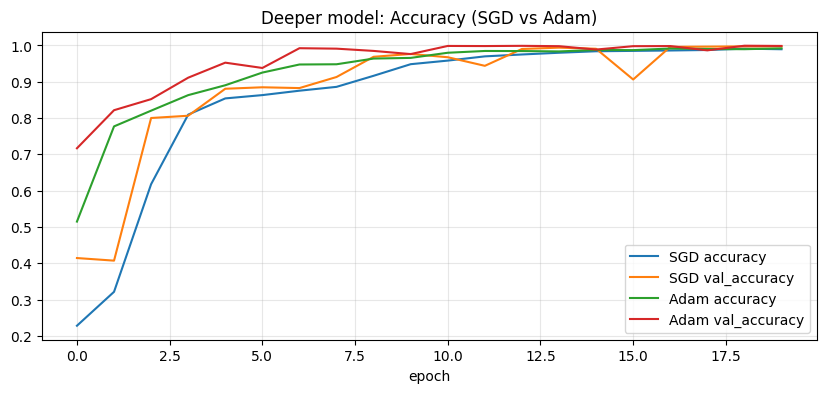

In [ ]:
# 2) Optimizer analysis on the deeper architecture: SGD vs Adam

def build_deep_model(use_dropout=True, use_batchnorm=True, weight_decay=1e-4, dropout_rate=0.3):
    l2r = keras.regularizers.l2(weight_decay)

    def conv_block(x, filters):
        x = layers.Conv2D(filters, (3,3), padding="same", use_bias=not use_batchnorm, kernel_regularizer=l2r)(x)
        if use_batchnorm:
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv2D(filters, (3,3), padding="same", use_bias=not use_batchnorm, kernel_regularizer=l2r)(x)
        if use_batchnorm:
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D((2,2))(x)
        if use_dropout:
            x = layers.Dropout(dropout_rate)(x)
        return x

    inp = layers.Input(shape=(*IMG_SIZE, 3))
    x = inp
    x = conv_block(x, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=l2r)(x)
    if use_dropout:
        x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=l2r)(x)
    if use_dropout:
        x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=l2r)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inp, out, name=f"deep_reg_do{int(use_dropout)}_bn{int(use_batchnorm)}")


def train_with_optimizer(opt_name="adam", epochs=20):
    model = build_deep_model(use_dropout=True, use_batchnorm=True, weight_decay=WEIGHT_DECAY, dropout_rate=DROPOUT_RATE)

    if opt_name.lower() == "adam":
        opt = keras.optimizers.Adam(learning_rate=1e-3)
    elif opt_name.lower() == "sgd":
        opt = keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9, nesterov=True)
    else:
        raise ValueError("opt_name must be 'adam' or 'sgd'")

    model.compile(
        optimizer=opt,
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    cb = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ]

    start = time.time()
    hist = model.fit(
        train_ds_prep,
        validation_data=val_ds_prep,
        epochs=epochs,
        callbacks=cb,
        class_weight=class_weight,
        verbose=1,
    )
    elapsed = time.time() - start

    metrics = eval_on_val(model, val_ds_prep.ignore_errors())
    return model, hist, elapsed, metrics

RUN_OPTIMIZER_EXPERIMENT = True

if RUN_OPTIMIZER_EXPERIMENT:
    sgd_model, sgd_hist, sgd_time, sgd_metrics = train_with_optimizer("sgd", epochs=20)
    adam_model, adam_hist, adam_time, adam_metrics = train_with_optimizer("adam", epochs=20)

    print("\nSGD metrics:", {k: v for k, v in sgd_metrics.items() if k != "report_dict"})
    print(f"SGD training time: {sgd_time:.1f}s")
    print("\nAdam metrics:", {k: v for k, v in adam_metrics.items() if k != "report_dict"})
    print(f"Adam training time: {adam_time:.1f}s")

    plot_histories({"SGD": sgd_hist, "Adam": adam_hist}, keys=("loss", "val_loss"), title="Deeper model: Loss (SGD vs Adam)")
    plot_histories({"SGD": sgd_hist, "Adam": adam_hist}, keys=("accuracy", "val_accuracy"), title="Deeper model: Accuracy (SGD vs Adam)")

Epoch 1/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.3897 - loss: 1.5687 - val_accuracy: 0.6776 - val_loss: 0.8722 - learning_rate: 0.0010
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7567 - loss: 0.7202 - val_accuracy: 0.8755 - val_loss: 0.3622 - learning_rate: 0.0010
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8171 - loss: 0.5525 - val_accuracy: 0.8799 - val_loss: 0.2750 - learning_rate: 0.0010
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8375 - loss: 0.5055 - val_accuracy: 0.8805 - val_loss: 0.2683 - learning_rate: 0.0010
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8496 - loss: 0.4733 - val_accuracy: 0.8855 - val_loss: 0.2476 - learning_rate: 0.0010
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8468 - loss: 0.4552 - val_accuracy: 0.9079 - val_loss: 0.2385 - learning_rate: 0.0010
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8536 - loss: 0

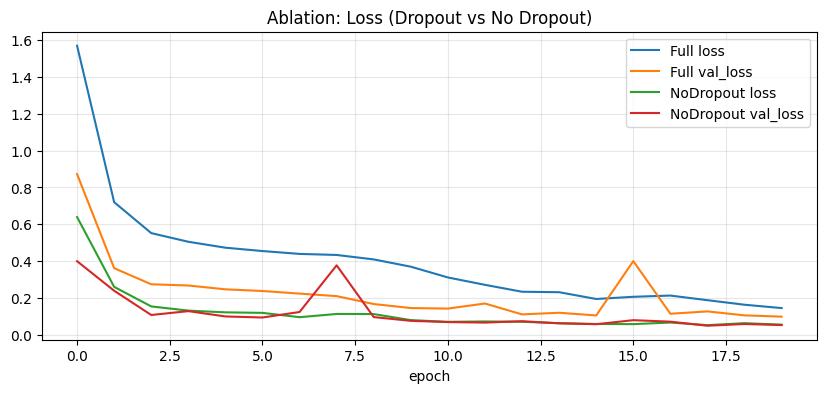

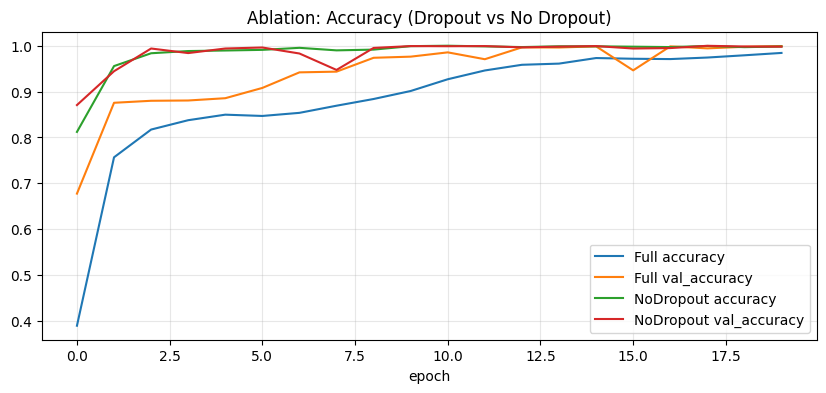

In [ ]:
# 3) Ablation study: remove Dropout (keep BatchNorm) and compare

RUN_ABLATION = True

if RUN_ABLATION:
    # Full model (Dropout+BN)
    full_model, full_hist, full_time, full_metrics = train_with_optimizer("adam", epochs=20)

    # Ablated model: no dropout
    no_do = build_deep_model(use_dropout=False, use_batchnorm=True, weight_decay=WEIGHT_DECAY, dropout_rate=DROPOUT_RATE)
    no_do.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    cb = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ]
    start = time.time()
    no_do_hist = no_do.fit(
        train_ds_prep,
        validation_data=val_ds_prep,
        epochs=20,
        callbacks=cb,
        class_weight=class_weight,
        verbose=1,
    )
    no_do_time = time.time() - start
    no_do_metrics = eval_on_val(no_do, val_ds_prep.ignore_errors())

    print("\nFull (Dropout+BN) metrics:", {k: v for k, v in full_metrics.items() if k != "report_dict"})
    print(f"Full training time: {full_time:.1f}s")

    print("\nAblation (No Dropout, BN kept) metrics:", {k: v for k, v in no_do_metrics.items() if k != "report_dict"})
    print(f"No-Dropout training time: {no_do_time:.1f}s")

    plot_histories({"Full": full_hist, "NoDropout": no_do_hist}, keys=("loss", "val_loss"), title="Ablation: Loss (Dropout vs No Dropout)")
    plot_histories({"Full": full_hist, "NoDropout": no_do_hist}, keys=("accuracy", "val_accuracy"), title="Ablation: Accuracy (Dropout vs No Dropout)")

In [ ]:
# Build datasets resized for ImageNet models (224x224)

IMG_SIZE_TL = (64 , 64)
BATCH_SIZE_TL = 32

train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE_TL,
    shuffle=True,
)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE_TL,
    shuffle=False,
)

train_ds_tl = train_ds_tl.ignore_errors()
val_ds_tl = val_ds_tl.ignore_errors()

from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

augment_tl = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
    ],
    name="augment_tl",
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds_tl_prep = (
    train_ds_tl
    .map(lambda x, y: (preprocess_input(augment_tl(x, training=True)), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

val_ds_tl_prep = (
    val_ds_tl
    .map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

print("Transfer-learning input size:", IMG_SIZE_TL)
print("Classes:", class_names)

Found 16100 files belonging to 5 classes.
Using 12880 files for training.
Found 16100 files belonging to 5 classes.
Using 3220 files for validation.
Transfer-learning input size: (64, 64)
Classes: ['Cautions', 'Crossings', 'DIrection', 'No Entry', 'SpeedLimit']


In [ ]:
# 2.6.1 Load and adapt a pre-trained model (feature extraction)

base_model = MobileNetV2(
    input_shape=(*IMG_SIZE_TL, 3),
    include_top=False,          # removes ImageNet classifier head
    weights="imagenet",
)
base_model.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE_TL, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

transfer_model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

transfer_model.summary()

/tmp/ipykernel_138134/3985322668.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/25
    373/Unknown 44s 69ms/step - accuracy: 0.7885 - loss: 0.6881

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


373/373 ━━━━━━━━━━━━━━━━━━━━ 60s 112ms/step - accuracy: 0.8628 - loss: 0.4671 - val_accuracy: 0.9609 - val_loss: 0.1138 - learning_rate: 0.0010
Epoch 2/25
373/373 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - accuracy: 0.9241 - loss: 0.2595 - val_accuracy: 0.9645 - val_loss: 0.0905 - learning_rate: 0.0010
Epoch 3/25
373/373 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9372 - loss: 0.2161 - val_accuracy: 0.9738 - val_loss: 0.0681 - learning_rate: 0.0010
Epoch 4/25
373/373 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9494 - loss: 0.1854 - val_accuracy: 0.9834 - val_loss: 0.0521 - learning_rate: 0.0010
Epoch 5/25
373/373 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9564 - loss: 0.1608 - val_accuracy: 0.9853 - val_loss: 0.0417 - learning_rate: 0.0010
Epoch 6/25
373/373 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9639 - loss: 0.1309 - val_accuracy: 0.9782 - val_loss: 0.0570 - learning_rate: 0.0010
Epoch 7/25
373/373 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9669 - loss: 0.1232 - val_

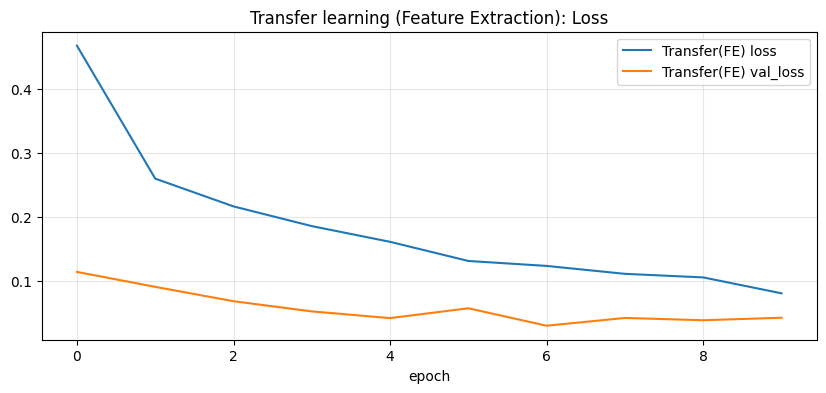

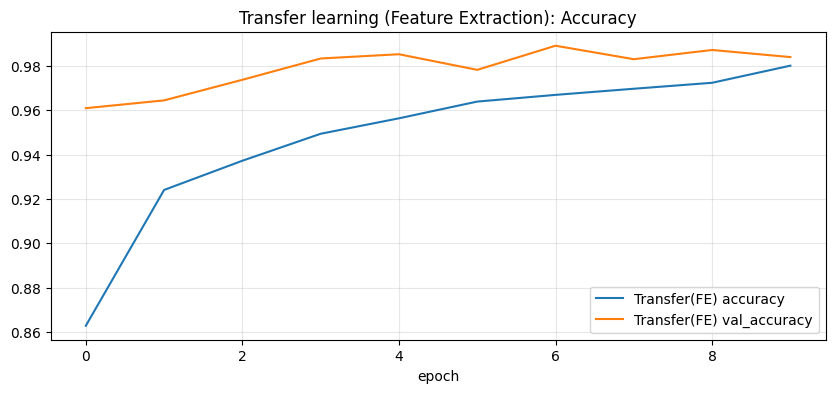

In [ ]:
# 2.6.2 Training strategy 1: Feature extraction (frozen base)

FE_EPOCHS = 25

fe_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

start = time.time()
fe_history = transfer_model.fit(
    train_ds_tl_prep,
    validation_data=val_ds_tl_prep,
    epochs=FE_EPOCHS,
    callbacks=fe_callbacks,
    class_weight=class_weight,
)
fe_time = time.time() - start
print(f"Feature-extraction training time: {fe_time:.1f}s")

plot_histories({"Transfer(FE)": fe_history}, keys=("loss", "val_loss"), title="Transfer learning (Feature Extraction): Loss")
plot_histories({"Transfer(FE)": fe_history}, keys=("accuracy", "val_accuracy"), title="Transfer learning (Feature Extraction): Accuracy")

Epoch 1/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.9742 - loss: 0.1002 - val_accuracy: 0.9834 - val_loss: 0.0556 - learning_rate: 1.0000e-05
Epoch 2/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9806 - loss: 0.0753 - val_accuracy: 0.9869 - val_loss: 0.0395 - learning_rate: 1.0000e-05
Epoch 3/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9847 - loss: 0.0663 - val_accuracy: 0.9859 - val_loss: 0.0426 - learning_rate: 1.0000e-05
Epoch 4/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9883 - loss: 0.0509 - val_accuracy: 0.9853 - val_loss: 0.0513 - learning_rate: 1.0000e-05
Epoch 5/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9906 - loss: 0.0386 - val_accuracy: 0.9875 - val_loss: 0.0390 - learning_rate: 5.0000e-06
Epoch 6/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9922 - loss: 0.0326 - val_accuracy: 0.9930 - val_loss: 0.0248 - learning_rate: 5.0000e-06
Epoch 7/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accur

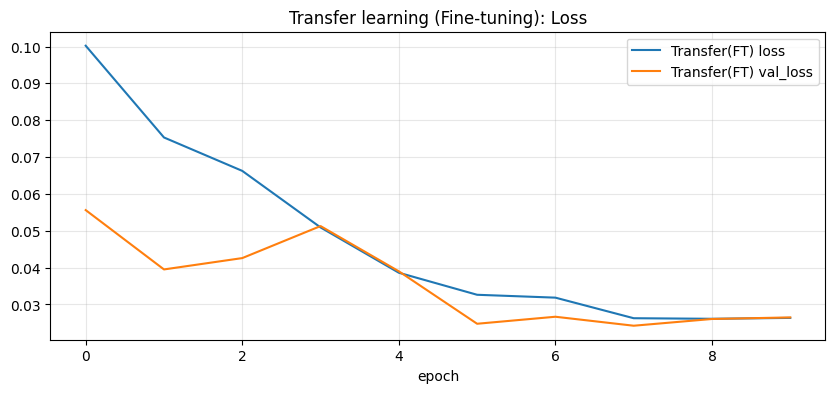

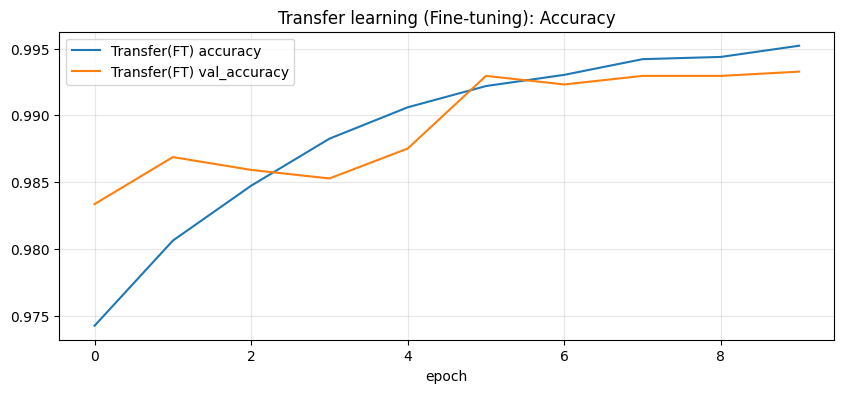

In [ ]:
# 2.6.2 Training strategy 2: Fine-tuning (unfreeze part of the base, low LR)

base_model.trainable = True

# Keep BatchNorm layers frozen for stability during fine-tuning
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Optionally, only unfreeze the top N layers (smaller N = safer)
FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

FT_EPOCHS = 10

ft_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

start = time.time()
ft_history = transfer_model.fit(
    train_ds_tl_prep,
    validation_data=val_ds_tl_prep,
    epochs=FT_EPOCHS,
    callbacks=ft_callbacks,
    class_weight=class_weight,
)
ft_time = time.time() - start
print(f"Fine-tuning training time: {ft_time:.1f}s")

plot_histories({"Transfer(FT)": ft_history}, keys=("loss", "val_loss"), title="Transfer learning (Fine-tuning): Loss")
plot_histories({"Transfer(FT)": ft_history}, keys=("accuracy", "val_accuracy"), title="Transfer learning (Fine-tuning): Accuracy")

In [ ]:
# 2.6.3 Evaluation (same metrics as Part A) + comparison

transfer_metrics = eval_on_val(transfer_model, val_ds_tl_prep.ignore_errors())

print("Transfer-learning metrics (Validation):")
print({k: v for k, v in transfer_metrics.items() if k != "report_dict"})

# Compare vs Part A (if you already computed these above)
try:
    print("\nBaseline vs Deeper vs Transfer (val):")
    print("Baseline:", {k: v for k, v in baseline_metrics.items() if k != "report_dict"})
    print("Deeper:  ", {k: v for k, v in deep_metrics.items() if k != "report_dict"})
    print("Transfer:", {k: v for k, v in transfer_metrics.items() if k != "report_dict"})
except NameError:
    print("\nNote: baseline_metrics/deep_metrics were not found in memory. Run the Part A comparison cell first if needed.")

Transfer-learning metrics (Validation):
{'accuracy': 0.9929577464788732, 'macro_f1': 0.19929328621908127, 'weighted_f1': 0.9964664310954064}

Baseline vs Deeper vs Transfer (val):
Baseline: {'accuracy': 0.9956427015250545, 'macro_f1': 0.9926144514867452, 'weighted_f1': 0.9956410412875424}
Deeper:   {'accuracy': 0.9978213507625272, 'macro_f1': 0.9974046429319261, 'weighted_f1': 0.9978216471025754}
Transfer: {'accuracy': 0.9929577464788732, 'macro_f1': 0.19929328621908127, 'weighted_f1': 0.9964664310954064}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Found 10 files.


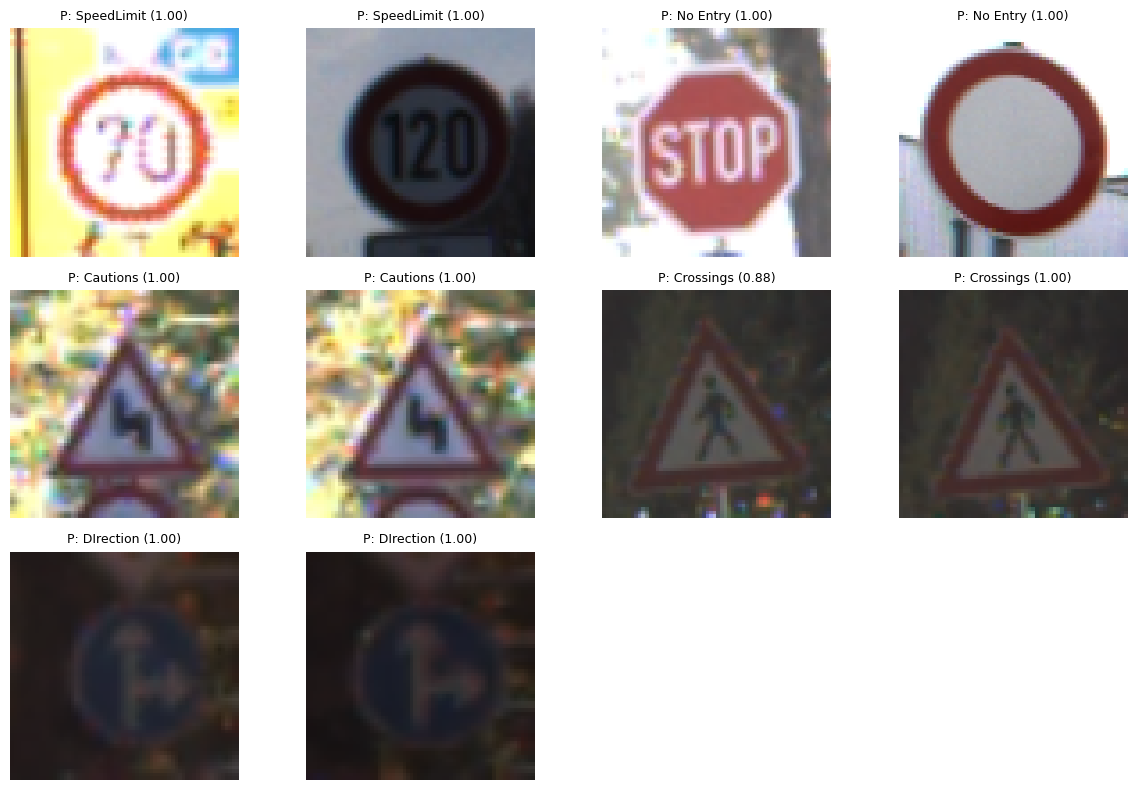

In [ ]:
# Predictions on Test data (no labels available in this folder)

test_ds_tl = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels=None,
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE_TL,
    shuffle=False,
)

test_ds_tl = test_ds_tl.ignore_errors()
test_ds_tl_prep = test_ds_tl.map(lambda x: preprocess_input(x), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Show predictions on a batch
for images in test_ds_tl_prep.take(1):
    probs = transfer_model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)

    plt.figure(figsize=(12, 8))
    for i in range(min(12, images.shape[0])):
        ax = plt.subplot(3, 4, i+1)
        # images are preprocessed for MobileNetV2; convert back roughly for display
        disp = (images[i].numpy() + 1.0) / 2.0  # [-1,1] -> [0,1]
        disp = np.clip(disp, 0, 1)
        plt.imshow(disp)
        ax.set_title(f"P: {class_names[int(preds[i])]} ({float(confs[i]):.2f})", fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()